In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
img = cv2.imread('flower.jpg')

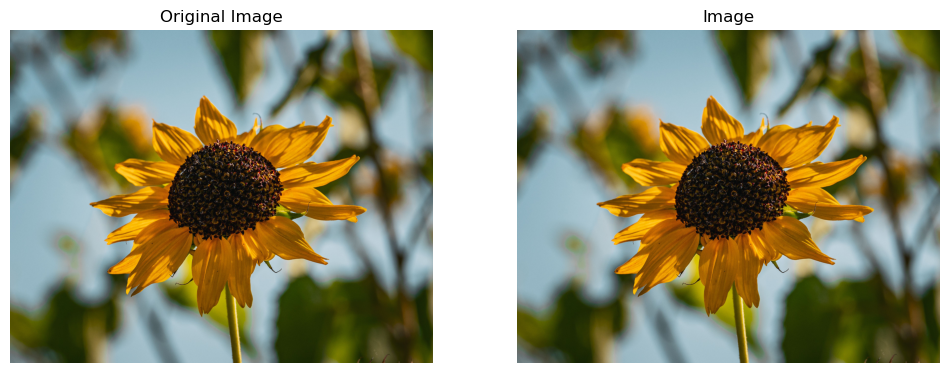

In [ ]:

if img is None:
    print("Error: Could not read the image.")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize = (12,5))
    plt.subplot(1,2,1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1,2,2)
    plt.imshow(img_rgb)
    plt.title('Image')
    plt.axis('off')
    plt.show()
    

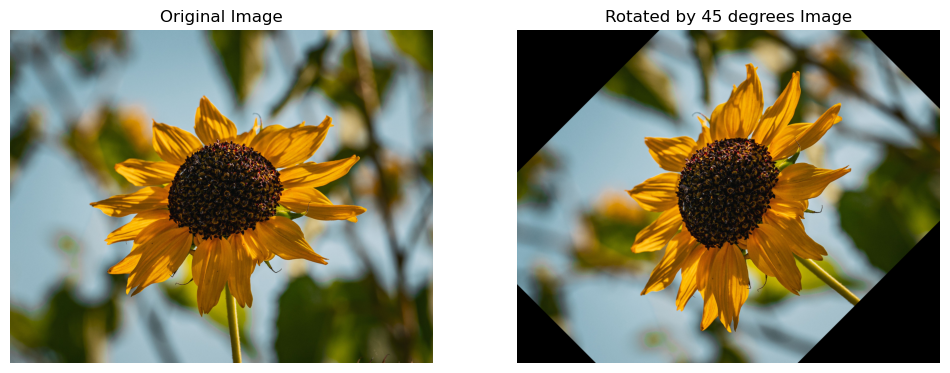

In [ ]:
#AFFINE -> LINEAR -> ROTATION

height, width = img.shape[:2]

center = (width // 2, height // 2)
angle = 45
scale = 1.0

M = cv2.getRotationMatrix2D(center, angle, scale) #rotation matrix
rotated = cv2.warpAffine(img, M, (width, height))

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rotated_rgb = cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(rotated_rgb)
plt.title('Rotated by 45 degrees Image')
plt.axis('off')

plt.show()


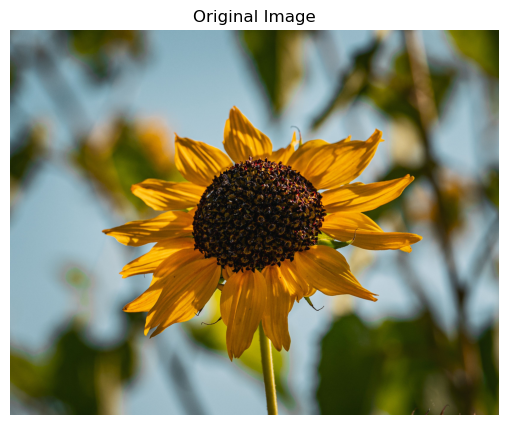

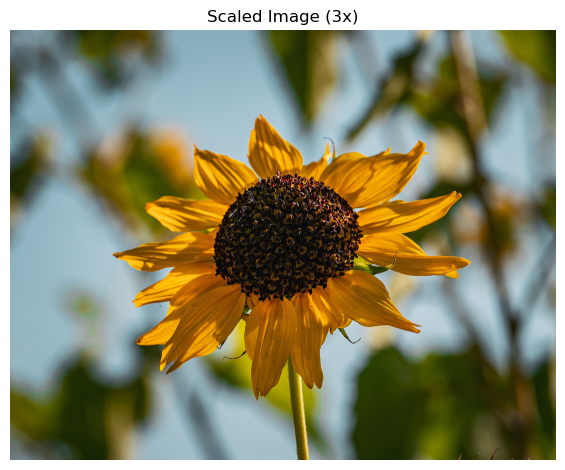

In [ ]:
#AFFINE -> LINEAR -> SCALE

scale_x = 3
scale_y = 3

scaled_img = cv2.resize(img, None, fx = scale_x, fy = scale_y, interpolation = cv2.INTER_LINEAR)
scaled_rgb = cv2.cvtColor(scaled_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (12, 5))
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

plt.imshow(scaled_rgb)
plt.title('Scaled Image (3x)')
plt.axis('off')
plt.tight_layout()
plt.show()


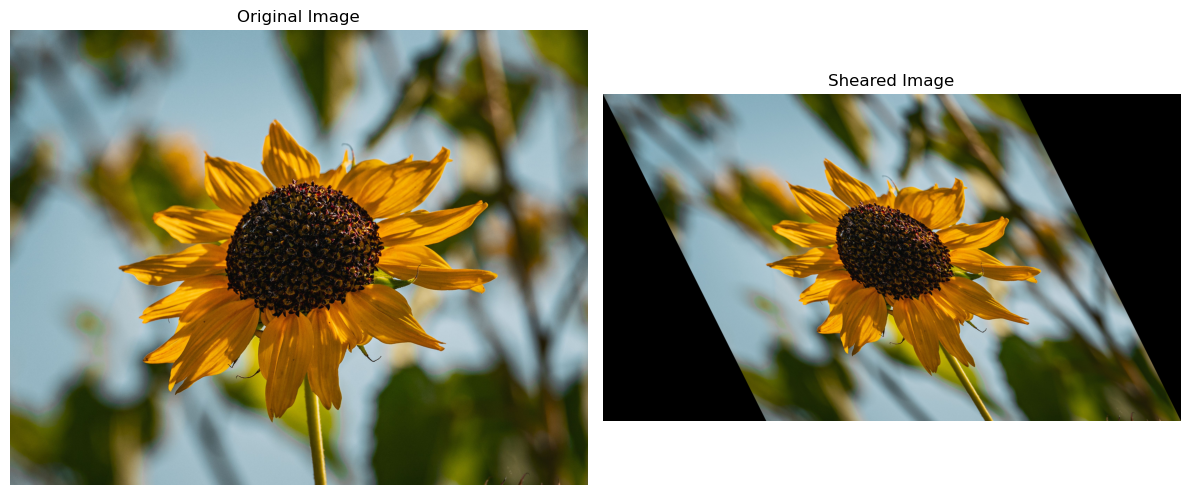

In [ ]:
#AFFINE -> LINEAR -> SHEAR


kx = 0.5

M = np.float32([
    [1, kx, 0], 
    [0, 1, 0]
])

new_width = int(width + abs(kx) * height)

sheared = cv2.warpAffine(img, M, (new_width, height))

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
sheared_rgb = cv2.cvtColor(sheared, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sheared_rgb)
plt.title('Sheared Image')
plt.axis('off')

plt.tight_layout()
plt.show()


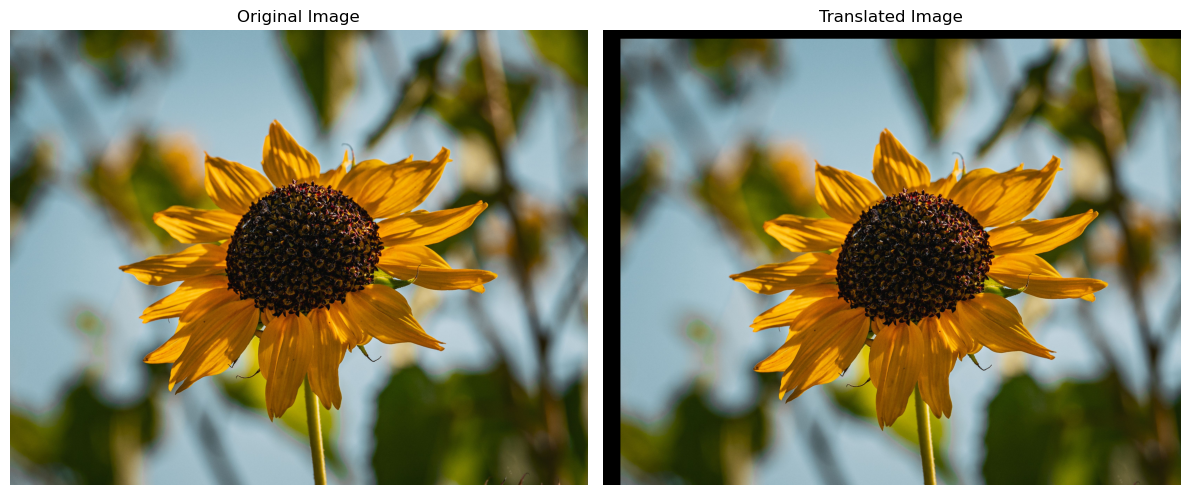

In [16]:
#ROTATION + UNIFORM SCALING + TRANSLATION 

height, width = img.shape[:2]

tx = 100
ty = 50

M = np.float32([
    [1, 0, tx], 
    [0 ,1, ty]
])

translated = cv2.warpAffine(img, M, (width, height))

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
translated_rgb = cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(translated_rgb)
plt.title('Translated Image')
plt.axis('off')

plt.tight_layout()
plt.show()

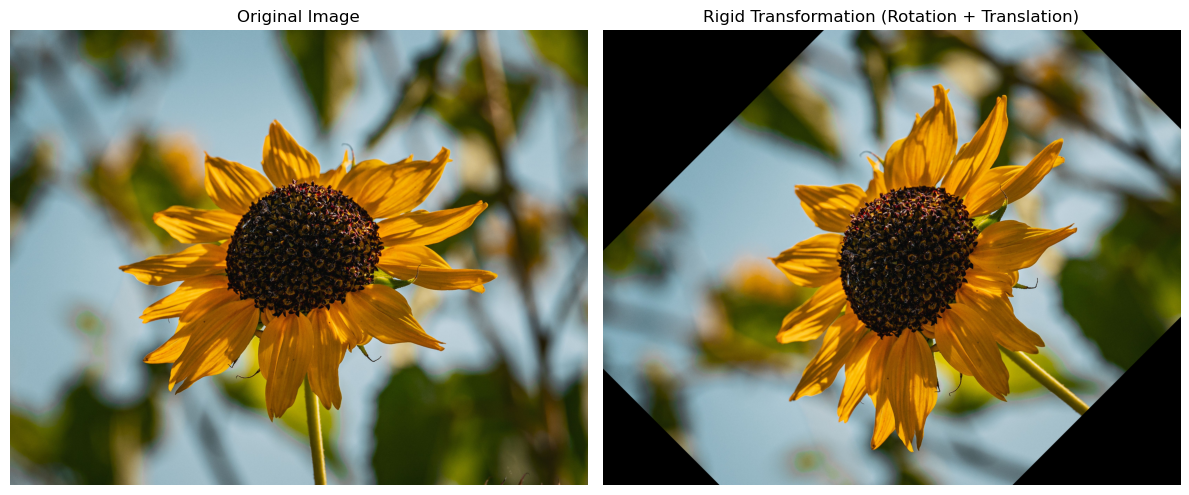

In [ ]:

#rigid transformation -> rotation + translation
height, width = img.shape[:2]
center = (width // 2, height // 2)
angle = 45
scale_factor = 1.0 #must be 1 in rigid translated

M = cv2.getRotationMatrix2D(center, angle, scale_factor) #rotation matrix 

#add translation to the rotation matrix
M[0, 2] += 100
M[1, 2] += 50

#apply translation 

rigid = cv2.warpAffine(img, M, (width, height)) #apply transformation

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rigid_rgb = cv2.cvtColor(rigid, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(rigid_rgb)
plt.title('Rigid Transformation (Rotation + Translation)')
plt.axis('off')

plt.tight_layout()
plt.show()


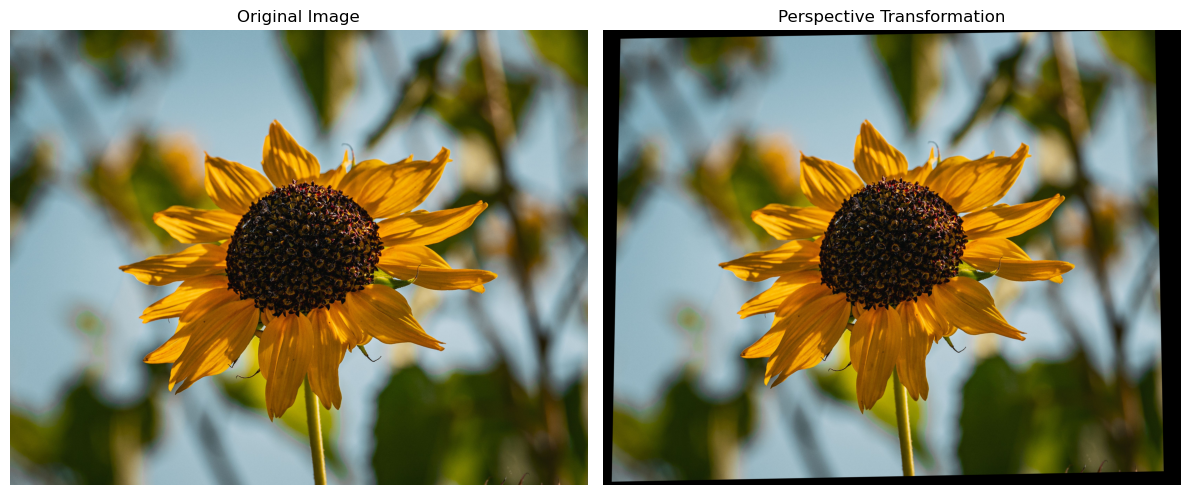

In [18]:
#projective transformation -> perspective transformation

#original corners of the image
src_points = np.float32([
    [0, 0], 
    [width - 1, 0], 
    [width - 1, height - 1], 
    [0, height - 1]
])

#new perspective positions
dst_points = np.float32([
    [100, 50], 
    [width - 150, 0], 
    [width - 100, height - 80], 
    [50, height - 20]
])

#homography matrix

H = cv2.getPerspectiveTransform(src_points, dst_points)

#apply perspective transformation

perspective = cv2.warpPerspective(img, H, (width, height))

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
perspective_rgb = cv2.cvtColor(perspective, cv2.COLOR_BGR2RGB)

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(perspective_rgb)
plt.title('Perspective Transformation')
plt.axis('off')

plt.tight_layout()
plt.show()
